In [1]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import muon as mu
import anndata as ad
import nichepca as npc
import scipy.sparse as sparse

import os
import sys
from pathlib import Path

# Add the src directory to the path if it's not already there
notebook_dir = Path(os.getcwd())
if notebook_dir.name == 'src':
    sys.path.append(".")  # Add current directory
else:
    sys.path.append(str(notebook_dir / "src"))  # Add src directory

from config import H5AD_DIR, get_h5ad_path

%load_ext autoreload
%autoreload 2
%matplotlib inline

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata

In [2]:
ad_sp = sc.read_h5ad(get_h5ad_path("c_sp_ad.h5ad"))

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


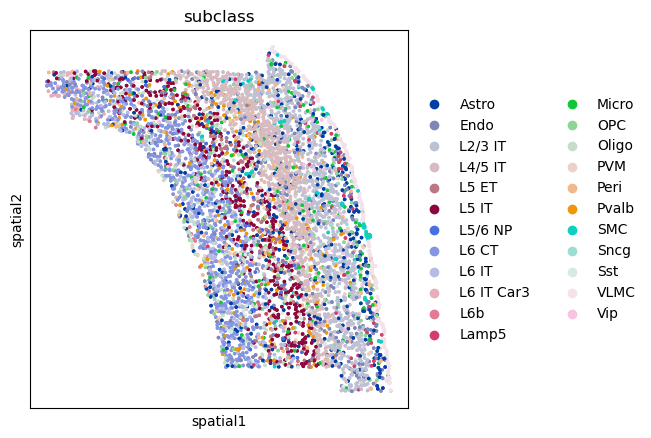

In [3]:
sq.pl.spatial_scatter(
    ad_sp, shape=None, color="subclass", size=10
)

In [4]:
sq.gr.spatial_neighbors(ad_sp, coord_type="generic")

100%|██████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 826.12/s]


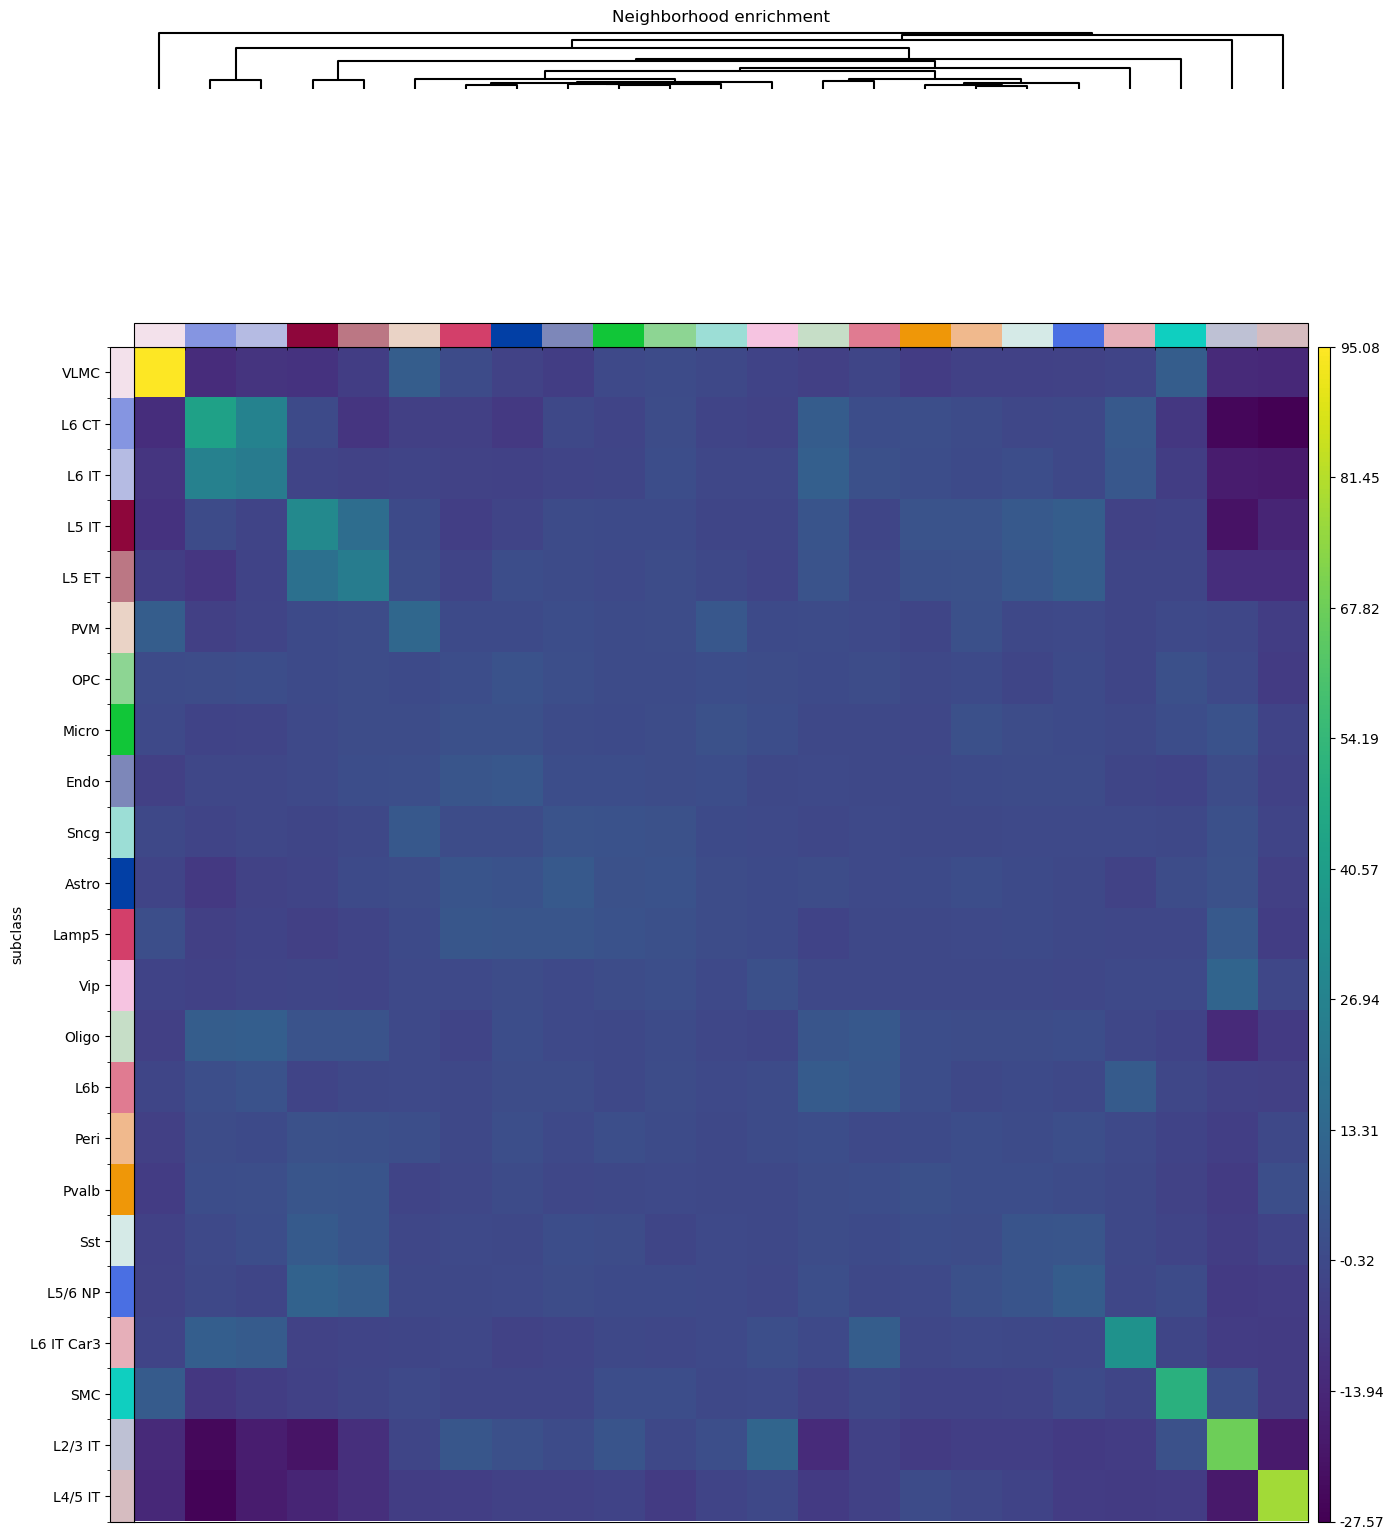

In [5]:
sq.gr.nhood_enrichment(ad_sp, cluster_key="subclass")
sq.pl.nhood_enrichment(ad_sp, cluster_key="subclass", method="ward")

In [9]:
sq.gr.spatial_autocorr(ad_sp, mode="geary")

maybe obere linie muss weg siehe die ersten 2

In [7]:
geary_gene_names_list = ad_sp.uns["gearyC"].head(n=20).index.tolist()
print(geary_gene_names_list)

['Rorb', 'Igf2', 'Gfap', 'Rspo1', 'Cux2', 'Lamp5', 'Calb1', 'Unc5d', 'Fam19a2', 'Slc17a6', 'Otof', 'Serpinf1', 'Nr4a2', 'Sulf1', 'Prr16', 'Tac2', 'Camk2d', 'Bcl11b', 'Cdh9', 'Cdh12']


In [12]:
sq.gr.spatial_autocorr(ad_sp, mode="moran")

In [16]:
moran_gene_names_list = ad_sp.uns["moranI"].head(n=20).index.tolist()
print(moran_gene_names_list)

['Gfap', 'Igf2', 'Rorb', 'Rspo1', 'Cux2', 'Lamp5', 'Unc5d', 'Calb1', 'Fam19a2', 'Slc17a6', 'Serpinf1', 'Otof', 'Sulf1', 'Acta2', 'Prr16', 'Tac2', 'Camk2d', 'Cdh9', 'Cdh12', 'Bcl11b']


## todo: SVG on tangram extended spatial

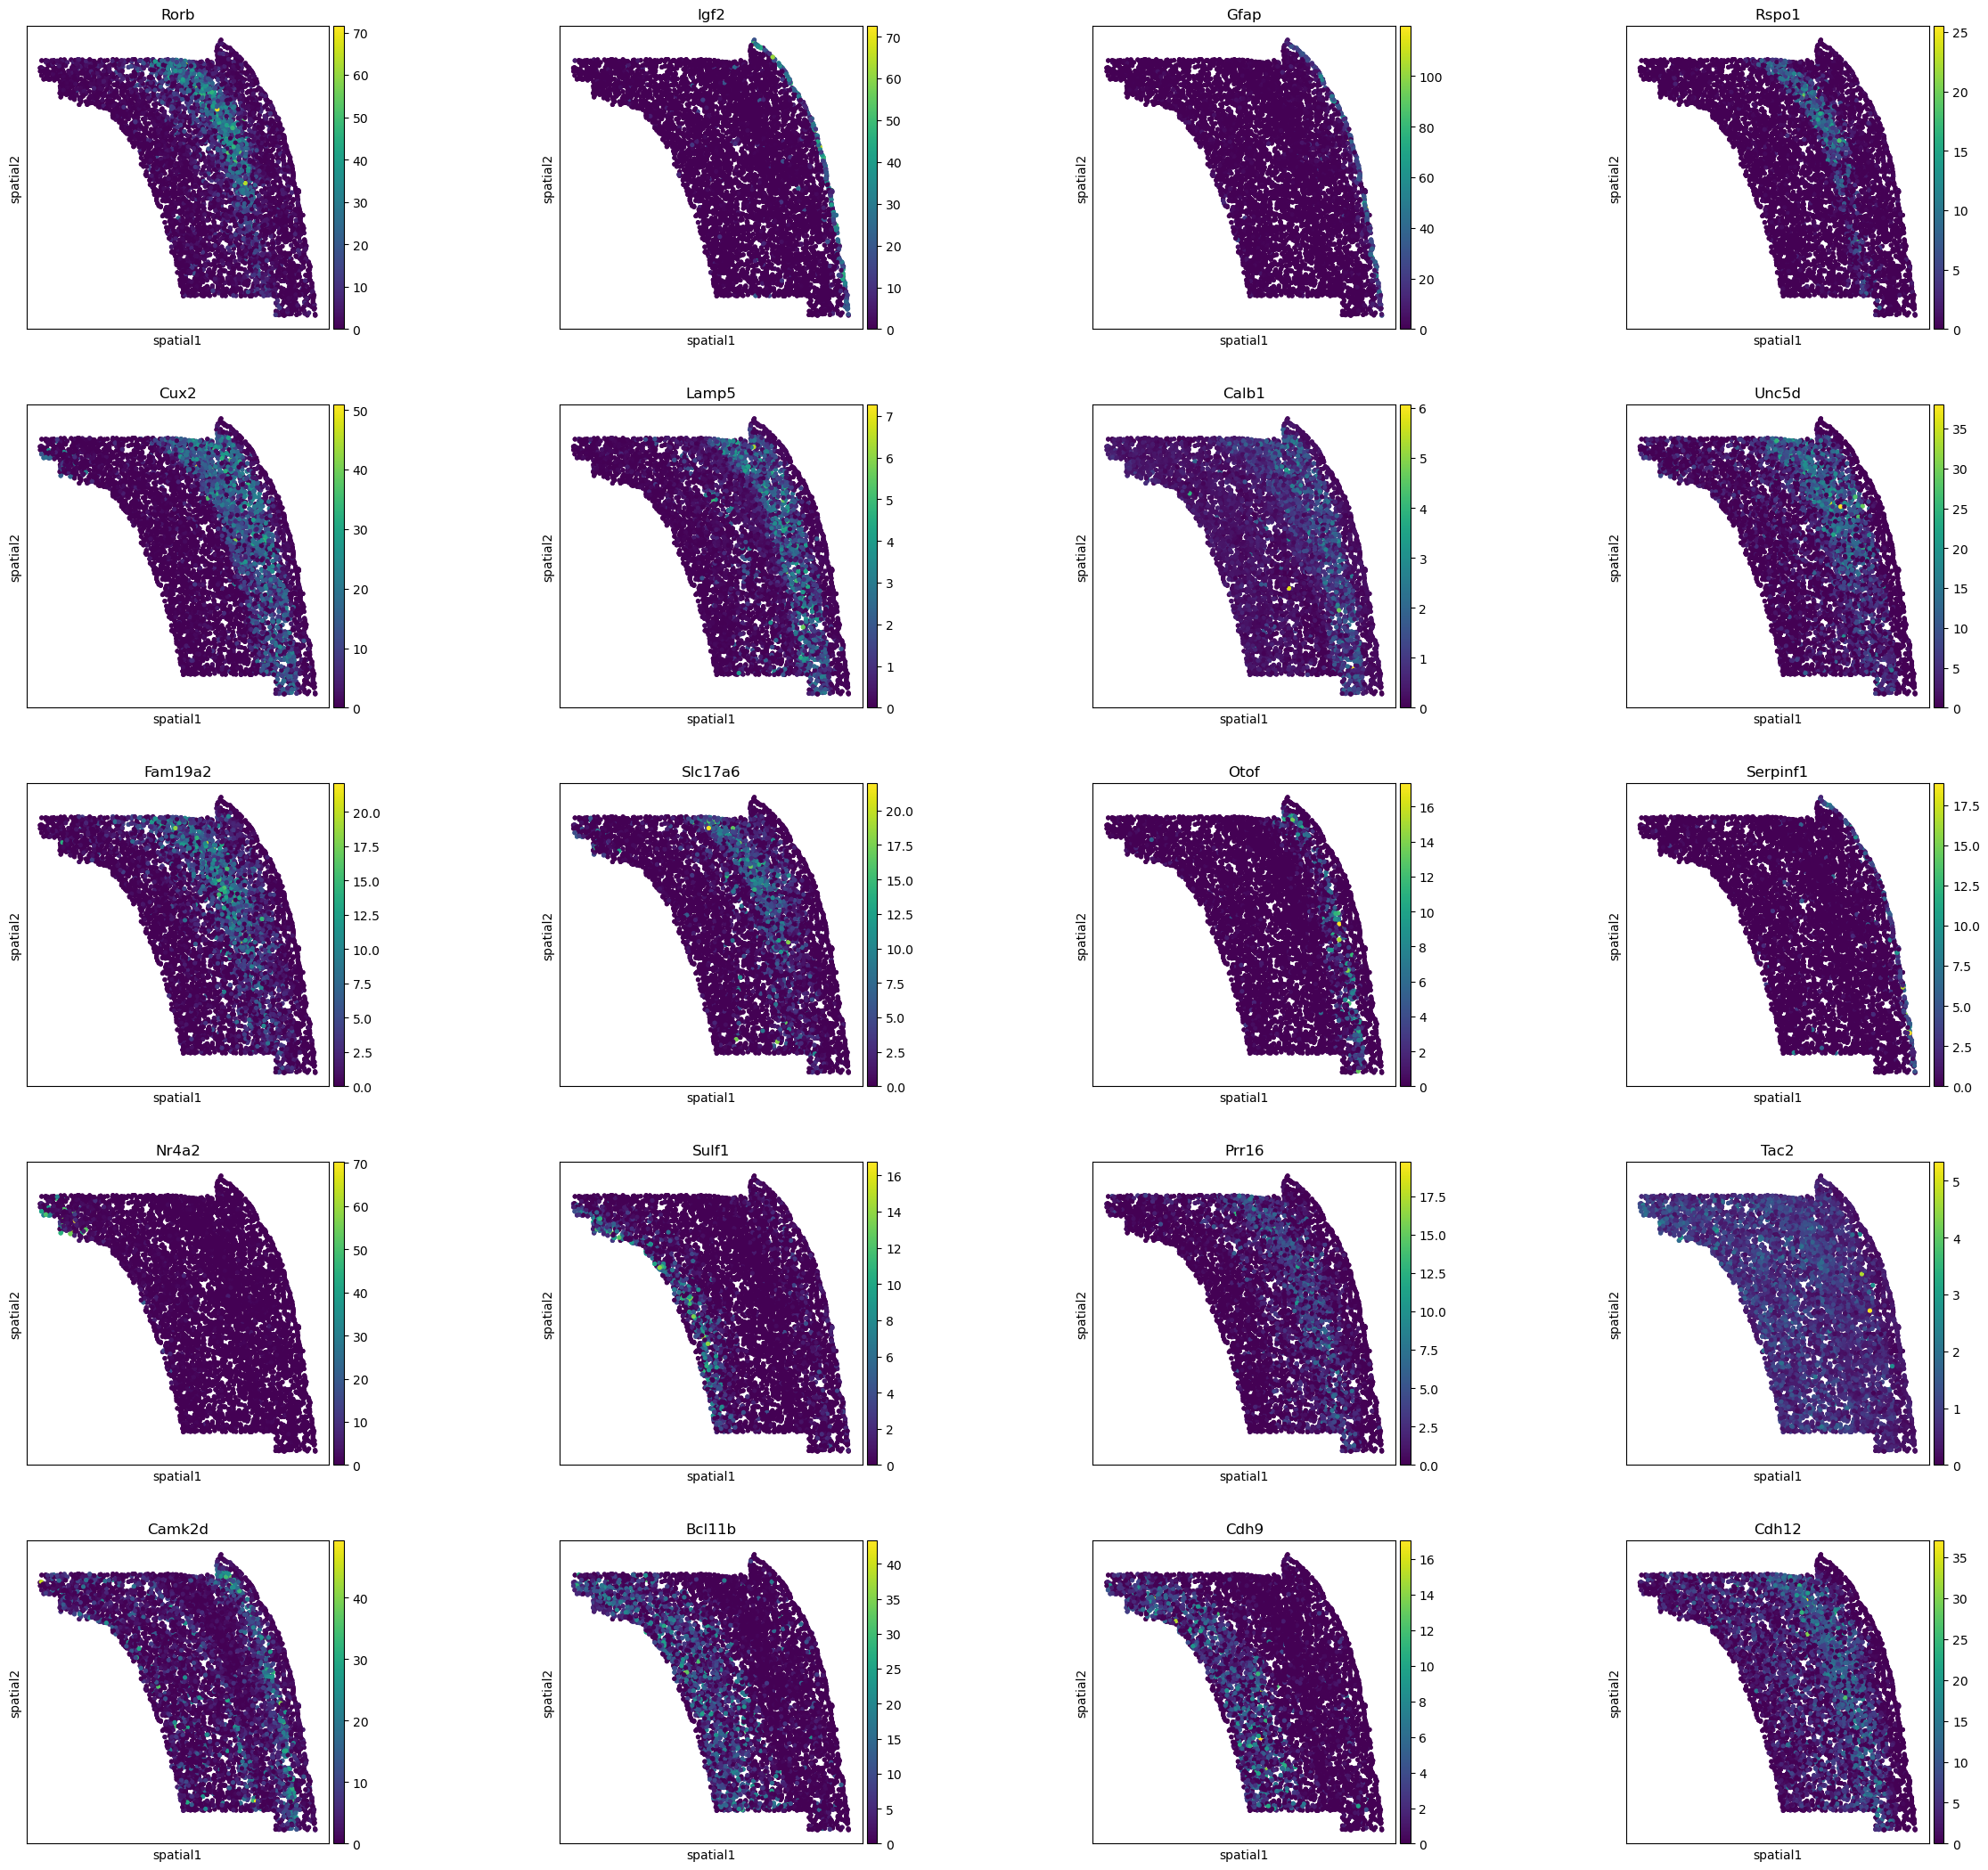

In [17]:
sq.pl.spatial_scatter(
    ad_sp, shape=None, color=geary_gene_names_list, size=30
)

In [18]:
# Convert the lists to sets
moran_genes_set = set(moran_gene_names_list)
geary_genes_set = set(geary_gene_names_list)

# Find the intersection using the intersection() method or the & operator
overlapping_genes = moran_genes_set.intersection(geary_genes_set)
# Or using the & operator:
# overlapping_genes = moran_genes_set & geary_genes_set

# Get the number of overlapping genes
num_overlapping_genes = len(overlapping_genes)

print(f"Number of genes overlapping in the top 20 for both measures: {num_overlapping_genes}")
print(f"Overlapping genes: {overlapping_genes}")

Number of genes overlapping in the top 20 for both measures: 19
Overlapping genes: {'Lamp5', 'Fam19a2', 'Rspo1', 'Igf2', 'Tac2', 'Cux2', 'Calb1', 'Otof', 'Camk2d', 'Serpinf1', 'Prr16', 'Gfap', 'Cdh9', 'Slc17a6', 'Unc5d', 'Bcl11b', 'Rorb', 'Cdh12', 'Sulf1'}


In [19]:
# Genes in top 20 Moran that are NOT in top 20 Geary
unique_to_moran = moran_genes_set - geary_genes_set

# Genes in top 20 Geary that are NOT in top 20 Moran
unique_to_geary = geary_genes_set - moran_genes_set

print(f"Genes in top 20 Moran only: {unique_to_moran}")
print(f"Genes in top 20 Geary only: {unique_to_geary}")

Genes in top 20 Moran only: {'Acta2'}
Genes in top 20 Geary only: {'Nr4a2'}


In [20]:
ad_sp.uns["gearyC"]

,C,pval_norm,var_norm,pval_norm_fdr_bh
Rorb,0.431786,0.000000e+00,0.000058,0.000000e+00
Igf2,0.434353,0.000000e+00,0.000058,0.000000e+00
Gfap,0.444546,0.000000e+00,0.000058,0.000000e+00
Rspo1,0.461562,0.000000e+00,0.000058,0.000000e+00
Cux2,0.472873,0.000000e+00,0.000058,0.000000e+00
...,...,...,...,...
Col15a1,1.030868,2.570179e-05,0.000058,3.709236e-05
Ndst4,1.031023,2.356591e-05,0.000058,3.420424e-05
Th,1.031663,1.637607e-05,0.000058,2.404347e-05
Prok2,1.036432,8.811668e-07,0.000058,1.364734e-06
